# **🏦 Solving Real-World Imbalanced Data: Bank Churn Prediction with Advanced ML**

## 📝 Descripción: <a id='descripción'></a>

  Los clientes de Beta Bank se están yendo, cada mes, poco a poco. Los banqueros descubrieron que es más barato salvar a los clientes existentes que atraer nuevos. Necesitamos predecir si un cliente dejará el banco pronto. Tú tienes los datos sobre el comportamiento pasado de los clientes y la terminación de contratos con el banco.

  Crea un modelo con el máximo valor F1 posible. Para aprobar la revisión, necesitas un valor F1 de al menos 0.59. Verifica F1 para el conjunto de prueba. 
  Además, debes medir la métrica AUC-ROC y compararla con el valor F1.

## 🎯 Objetivo:

* Desarrollar un modelo que pueda analizar el comportamiento de los clientes y predecir si un cliente dejará el banco pronto.

## ⚙️ Configuración Inicial

Importé las librerías esenciales y mis funciones personalizadas, asegurando reproducibilidad con una semilla aleatoria.

In [1]:
# Importa las librerías basicas
import pandas as pd # manipulación y análisis de datos
import numpy as np # 
import matplotlib.pyplot as plt
import seaborn as sns

# Importa los modelo de machine learning para la clasificación
from sklearn.tree import DecisionTreeClassifier # árbol de decisión
from sklearn.ensemble import RandomForestClassifier # conjunto de árboles de decisión
from sklearn.linear_model import LogisticRegression # modelo lineal de regresión

# Importa herramientas para evaluación
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, precision_score, f1_score, roc_curve, confusion_matrix, precision_recall_curve
from sklearn.model_selection import train_test_split, GridSearchCV # dividir el dataset en conjuntos
from sklearn.preprocessing import StandardScaler, MinMaxScaler # 
from sklearn.utils import shuffle # 

# Funcion para el conteo de errores
def error_count(answers, predictions):
    return np.sum(np.array(answers) != np.array(predictions))

# Función para evaluar modelos
def evaluate_model(model, X_train, y_train, X_val, y_val):
    # Entrenamiento y predicción
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] # Para AUC-ROC
    
    # Cálculo de métricas
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    matrix = confusion_matrix(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_proba)
    
    # Impresión de métricas en formato organizado
    print("Métricas de Evaluación")
    print("-------------------------------")
    print(f"Exactitud (Accuracy): {accuracy:.4f}")
    print(f"Precisión: {precision:.4f}")
    print(f"Sensibilidad (Recall): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}\n")
    
    # Visualización de la matriz de confusión con Seaborn
    plt.figure(figsize=(4, 2))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Pred 0', 'Pred 1'], 
                yticklabels=['Real 0', 'Real 1'])
    plt.title('Matriz de Confusión', fontsize=14)
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.show()
    
    return matrix, accuracy, precision, recall, f1, roc_auc

# Funcion para sobremuestreo
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )

    return features_upsampled, target_upsampled

# Funcion para submuetreo
def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat(
        [features_zeros.sample(frac=fraction, random_state=12345)]
        + [features_ones]
    )
    target_downsampled = pd.concat(
        [target_zeros.sample(frac=fraction, random_state=12345)]
        + [target_ones]
    )

    features_downsampled, target_downsampled = shuffle(
        features_downsampled, target_downsampled, random_state=12345
    )

    return features_downsampled, target_downsampled

# Semilla aleatoria
r_seed = 12345

print("Configuración completada")

Configuración completada


## 📂 Lectura y Exploración de Datos

* Cargué el dataset y analicé su estructura.

In [2]:
# Carga el dataframe 
churn_raw = pd.read_csv('../datasets/Churn.csv')

# Exploración inicial
print("Dimensiones del dataset:", churn_raw.shape)
print("\nPrimeras filas:")
display(churn_raw.head())

print("\nInformación general:")
display(churn_raw.info())

print("\nResumen estadístico:")
display(churn_raw.describe())
print("Resumen categórico:")
display(churn_raw.describe(include="object"))

Dimensiones del dataset: (10000, 14)

Primeras filas:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


None


Resumen estadístico:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,9091.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,4.997690,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.894723,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,2.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Resumen categórico:


,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


## 🛠️ Preparación y Limpieza

* Imputé los nulos con la mediana en la columna 'Tenure'. 
* Eliminé las columnas 'RowNumber', 'CustomerId', 'Surname' por ser irrelevante para el modelo.

In [3]:
# Copia para limpieza
churn_clean = churn_raw.copy()

# Elimino columnas irrelevantes
churn_clean = churn_clean.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Valores ausentes en la columna de Tenure
print(f"{churn_clean['Tenure'].isna().sum()} valores ausentes, {churn_clean['Tenure'].isna().mean():.1%} del dataset")

# Filas en las que la columna tenga valores ausentes.
print('Filas con valores usentes:')
display(churn_clean[churn_clean['Tenure'].isna()])

# Sustitución de valores ausentes 
churn_clean['Tenure'] = churn_clean['Tenure'].fillna(churn_clean['Tenure'].median())

churn = churn_clean

909 valores ausentes, 9.1% del dataset
Filas con valores usentes:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
30,591,Spain,Female,39,NaN,0.00,3,1,0,140469.38,1
48,550,Germany,Male,38,NaN,103391.38,1,0,1,90878.13,0
51,585,Germany,Male,36,NaN,146050.97,2,0,0,86424.57,0
53,655,Germany,Male,41,NaN,125561.97,1,0,0,164040.94,1
60,742,Germany,Male,35,NaN,136857.00,1,0,0,84509.57,0
...,...,...,...,...,...,...,...,...,...,...,...
9944,744,Germany,Male,41,NaN,190409.34,2,1,1,138361.48,0
9956,520,France,Female,46,NaN,85216.61,1,1,0,117369.52,1
9964,479,France,Male,34,NaN,117593.48,2,0,0,113308.29,0
9985,659,France,Male,36,NaN,123841.49,2,1,0,96833.00,0


## 📊 Clasificación de Variables

* Seleccioné las características para el modelo y a la variable objetivo 'Tenure'.

In [4]:
# Divide en características y objetivo
features = churn.drop('Exited', axis=1)
target = churn['Exited']

## 🔢 Codificación y Escalado

* Apliqué One-Hot Encoding a las variables categóricas y normalicé las numéricas con MinMaxScaler.

In [5]:
# Codificación de 'Geography' y 'Gender'
features = pd.get_dummies(features, drop_first=True)
features.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2.0,0.00,1,1,1,101348.88,0,0,0
1,608,41,1.0,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8.0,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1.0,0.00,2,0,0,93826.63,0,0,0
4,850,43,2.0,125510.82,1,1,1,79084.10,0,1,0


In [6]:
# Escalado de las caracteristicas numericas
numeric = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
scaler = MinMaxScaler()
scaler.fit(features[numeric])
features[numeric] = scaler.transform(features[numeric])
features.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,0.538,0.324324,0.2,0.000000,0.000000,1.0,1.0,0.506735,0.0,0.0,0.0
1,0.516,0.310811,0.1,0.334031,0.000000,0.0,1.0,0.562709,0.0,1.0,0.0
2,0.304,0.324324,0.8,0.636357,0.666667,1.0,0.0,0.569654,0.0,0.0,0.0
3,0.698,0.283784,0.1,0.000000,0.333333,0.0,0.0,0.469120,0.0,0.0,0.0
4,1.000,0.337838,0.2,0.500246,0.000000,1.0,1.0,0.395400,0.0,1.0,0.0


## 🧩 Segmentación de Datos

* Dividí los datos en 60% entrenamiento, 20% validación y 20% prueba con una proporción de 3:1:1.

In [7]:
# Mezcla los datos para evita sesgos por orden
features, target = shuffle(features, target, random_state=r_seed)

# Primer split: 60% entrenamiento, 40% temporal
features_train, features_temp, target_train, target_temp = train_test_split(
    features, target, test_size=0.4, random_state=r_seed, stratify=target
)
# Segundo split: 50% validación, 50% prueba (20% cada uno del total)
features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp, target_temp, test_size=0.5, random_state=r_seed, stratify=target_temp
)

total_samples = len(features)
print(f"Tamaño conjunto de entrenamiento: {features_train.shape[0]} muestras {features_train.shape[0]/total_samples:.2}")
print(f"Tamaño conjunto de validación: {features_valid.shape[0]} muestras")
print(f"Tamaño conjunto de prueba: {features_test.shape[0]} muestras")

Tamaño conjunto de entrenamiento: 6000 muestras 0.6
Tamaño conjunto de validación: 2000 muestras
Tamaño conjunto de prueba: 2000 muestras


## 🤖 Entrenamiento de Modelos Base

* Implementé un entrenmiento base para evaluar su rendimiento de los siguientes modelos.

#### 📉 Regresión logística 📏

Regresión logística (Modelo Base)
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.8175
Precisión: 0.6547
Sensibilidad (Recall): 0.2230
F1-Score: 0.3327
AUC-ROC: 0.7771



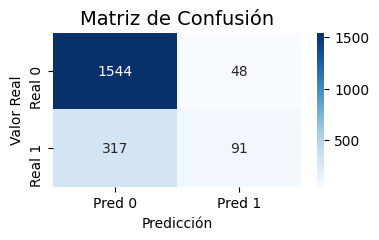

In [8]:
# Crea el modelo de regresión logística
base_lr = LogisticRegression(random_state=r_seed)
print("Regresión logística (Modelo Base)")
matrix_base_lr, accuracy_base_lr, precision_base_lr, recall_base_lr, f1_base_lr, roc_auc_base_lr   = evaluate_model(base_lr, 
                                                                                                                    features_train, target_train, 
                                                                                                                    features_valid, target_valid)

#### 🌲Arbol de decisión 🍃

Árbol de decisión (Modelo Base)
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.7870
Precisión: 0.4794
Sensibilidad (Recall): 0.5123
F1-Score: 0.4953
AUC-ROC: 0.6848



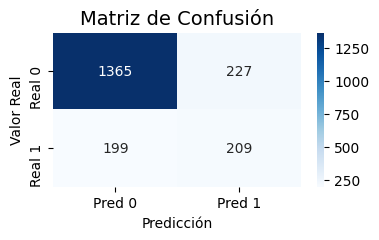

In [9]:
# Crea el modelo de árbol de decisión
base_dt = DecisionTreeClassifier(random_state=r_seed)
print("Árbol de decisión (Modelo Base)")
matrix_base_dt, accuracy_base_dt, precision_base_dt, recall_base_dt, f1_base_dt, roc_auc_base_dt = evaluate_model(base_dt, 
                                                                                                            features_train, target_train, 
                                                                                                            features_valid, target_valid)

#### 🌳 Bosque Aleatorio 🌳

Bosque Aleatorio (Modelo Base)
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.8600
Precisión: 0.7602
Sensibilidad (Recall): 0.4583
F1-Score: 0.5719
AUC-ROC: 0.8453



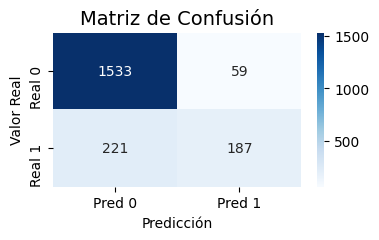

In [10]:
# Crear el modelo de bosque aleatorio
base_forest = RandomForestClassifier(random_state=r_seed)
print("Bosque Aleatorio (Modelo Base)")
matrix_base_rf, accuracy_base_rf, precision_base_rf, recall_base_rf, f1_base_rf, roc_auc_base_rf = evaluate_model(base_forest, 
                                                                                                                features_train, target_train, 
                                                                                                                features_valid, target_valid)

### 💡 Hallazgos:

- Exactitud:

    * El Bosque Aleatorio (0.85) tuvo la mayor exactitud, seguido de la Regresión Logística (0.818) y luego el Árbol de Decisión (0.787).
    * Esto sugiere que el Bosque Aleatorio generaliza mejor en términos de predicciones correctas totales.

- Precisión:

    * El Bosque Aleatorio (0.725) tuvo mejor precisión, seguido de la Regresión Logística (0.6618) y al final el Árbol de Decisión (0.4794).
    * El Bosque Aleatorio tiene mejor capacidad para evitar falsos positivos.

- Sensibilidad:

    * El Árbol de Decisión (0.5123) tuvo mayor sensibilidad, seguido del Bosque Aleatorio (0.4265) y luego la Regresión Logística (0.2206).
    * El Árbol de Decisión detecta mejor la clase minoritaria, pero a costa de más falsos positivos.
    * La Regresión Logística tiene un recall muy bajo, lo que indica que falla en identificar la mayoría de los casos positivos.

- F1-Score:

    * El Bosque Aleatorio (0.537) muestra el mejor balance, seguido por el Árbol de Decisión (0.4953) y al final la Regresión Logística (0.3309).
    * El Bosque Aleatorio logra un mejor equilibrio entre precisión y recall.

- AUC-ROC:

    * Bosque Aleatorio (0.8101) muestra la mejor capacidad de distinguir entre clases, seguido por la Regresión Logística (0.7768) y luego el Árbol de Decisión (0.6848).
    * El Bosque Aleatorio tiene la mejor discriminación entre clases, seguido de la Regresión Logística.


## ⚖️ Análisis del equilibrio de clases

* Muestro el desequilibrio de clases den el conjunto de datos

Distribución de clases en el conjunto completo:
0    0.7963
1    0.2037
Name: Exited, dtype: float64


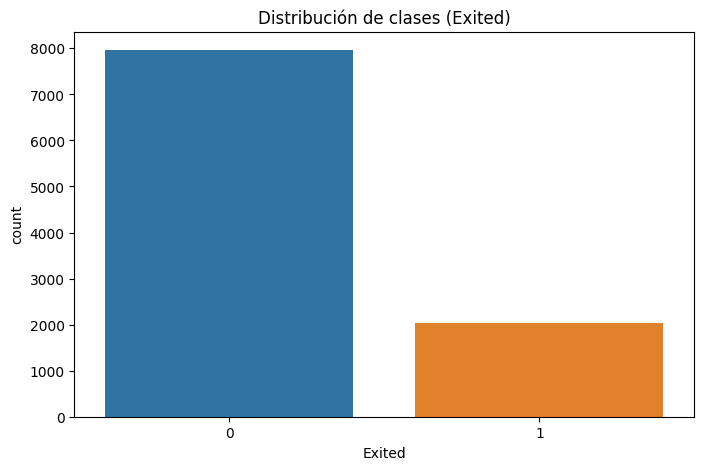

In [11]:
# Examina el equilibrio de clases
print("Distribución de clases en el conjunto completo:")
print(target.value_counts(normalize=True))

# Visualización
plt.figure(figsize=(8, 5))
sns.countplot(x=target)
plt.title('Distribución de clases (Exited)')
plt.show()

### 💡 Hallazgos:

* La clase mayoritaria 0 con el 79.6% del conjunto domina sobre la minoritaria 1 con el 20.4%.

* Los modelos base sin ajuste tienden a favorecer la clase mayoritaria, lo que explica:
    * Recall bajo en Regresión Logística ignora muchos casos positivos.
    * Precisión baja en Árbol de Decisión muchos falsos positivos.

## 🎚️ Mejora de Modelos

Para manejar el desequilibrio, probé tres enfoques: ajuste de pesos, sobremuestreo y submuestreo. Con GridSearchCV, optimicé los hiperparámetros del Random Forest como mejor modelo.

### 📉 Regresión logística 📏

Regresión logística (Peso de clase)
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.7205
Precisión: 0.3947
Sensibilidad (Recall): 0.6936
F1-Score: 0.5031
AUC-ROC: 0.7802



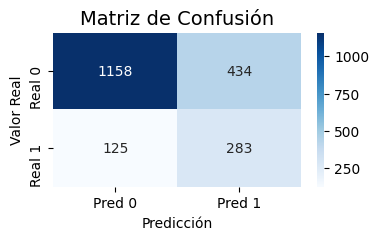

Regresión logística (Sobremuestreo)
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.4735
Precisión: 0.2698
Sensibilidad (Recall): 0.9265
F1-Score: 0.4179
AUC-ROC: 0.7809



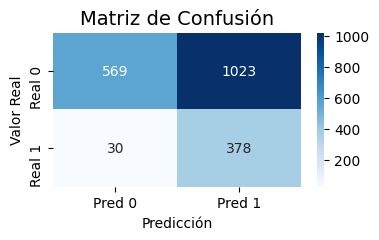

Regresión logística (Submuestreo)
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.4605
Precisión: 0.2672
Sensibilidad (Recall): 0.9436
F1-Score: 0.4164
AUC-ROC: 0.7807



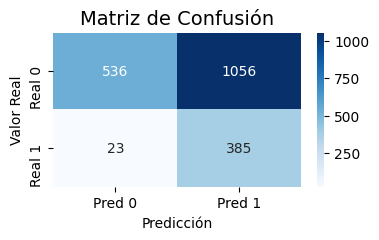

In [12]:
# Ajuste de peso de clase
weight_lr = LogisticRegression(random_state=r_seed, max_iter=1000, solver='liblinear', class_weight='balanced')
print("Regresión logística (Peso de clase)")
matrix_weight_lr, accuracy_weight_lr, precision_weight_lr, recall_weight_lr, f1_weight_lr, roc_auc_weight_lr = evaluate_model(weight_lr, 
                                                                                                                            features_train, target_train, 
                                                                                                                            features_valid, target_valid)

# Sobremuestreo
features_upsampled, target_upsampled = upsample(features_train, target_train, 10)

upsampled_lr = LogisticRegression(random_state=r_seed, max_iter=1000, solver='liblinear' )
print("Regresión logística (Sobremuestreo)")
matrix_up_lr, accuracy_up_lr, precision_up_lr, recall_up_lr, f1_up_lr, roc_auc_up_lr = evaluate_model(upsampled_lr, 
                                                                                                    features_upsampled, target_upsampled, 
                                                                                                    features_valid, target_valid)

# Submuestreo
features_downsampled, target_downsampled = downsample(features_train, target_train, 0.1)

downsample_lr = LogisticRegression(random_state=r_seed, max_iter=1000, solver='liblinear' )
print("Regresión logística (Submuestreo)")
matrix_down_lr, accuracy_down_lr, precision_down_lr, recall_down_lr, f1_down_lr, roc_auc_down_lr = evaluate_model(downsample_lr, 
                                                                                                                features_downsampled, target_downsampled,
                                                                                                                features_valid, target_valid)

- Ajuste de peso de clase:
    * Mejora el recall (0.6936 vs 0.2206) pero reduce la precisión y exactitud.
    * El F1-Score mejora (0.5031 vs 0.3309), indicando un mejor equilibrio.

- Sobremuestreo/Submuestreo:
    * Aumenta mucho el recall (0.9265 y 0.9436), pero la exactitud y precisión caen drásticamente.
    * El modelo se vuelve demasiado sensible a la clase minoritaria, generando muchos falsos positivos.

### 🌲Árbol de decisión 🍃

Árbol de decisión (Peso de clase)
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.7905
Precisión: 0.4872
Sensibilidad (Recall): 0.5123
F1-Score: 0.4994
AUC-ROC: 0.6870



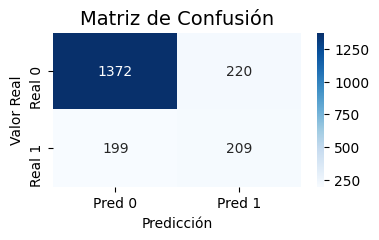

Árbol de decisión (Sobremuestreo)
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.7990
Precisión: 0.5075
Sensibilidad (Recall): 0.5000
F1-Score: 0.5037
AUC-ROC: 0.6878



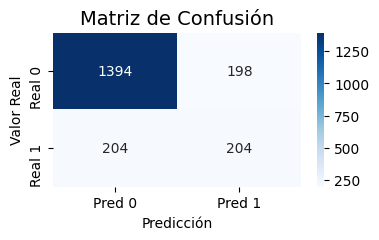

Árbol de decisión (Submuestreo)
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.6095
Precisión: 0.3177
Sensibilidad (Recall): 0.7966
F1-Score: 0.4542
AUC-ROC: 0.6791



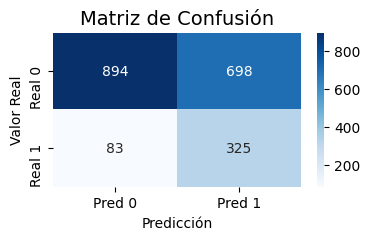

In [13]:
# Crear el modelo de árbol de decisión
weight_dt = DecisionTreeClassifier(random_state=r_seed, class_weight='balanced')
print("Árbol de decisión (Peso de clase)")
matrix_weight_dt, accuracy_weight_dt, precision_weight_dt, recall_weight_dt, f1_weight_dt, roc_auc_weight_dt = evaluate_model(weight_dt, 
                                                                                                                            features_train, target_train, 
                                                                                                                            features_valid, target_valid)

# Sobremuestreo
features_upsampled, target_upsampled = upsample(features_train, target_train, 10)

upsampled_dt = DecisionTreeClassifier(random_state=r_seed)
print("Árbol de decisión (Sobremuestreo)")
matrix_up_dt, accuracy_up_dt, precision_up_dt, recall_up_dt, f1_up_dt, roc_auc_up_dt = evaluate_model(upsampled_dt, 
                                                                                                    features_upsampled, target_upsampled, 
                                                                                                    features_valid, target_valid)

# Submuestreo
features_downsampled, target_downsampled = downsample(features_train, target_train, 0.1)

downsample_dt = DecisionTreeClassifier(random_state=r_seed)
print("Árbol de decisión (Submuestreo)")
matrix_down_dt, accuracy_down_dt, precision_down_dt, recall_down_dt, f1_down_dt, roc_auc_down_dt = evaluate_model(downsample_dt, 
                                                                                                                features_downsampled, target_downsampled, 
                                                                                                                features_valid, target_valid)

- Ajuste de peso y sobremuestreo:
    * Impacto limitado en métricas (F1-Score ~0.5).

- Submuestreo:
    * Aumenta el recall (0.7966), pero la exactitud y precisión empeoran.

### 🌳 Bosque aleatorio 🌳

Bosque aleatorio (Peso de clase)
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.8565
Precisión: 0.7713
Sensibilidad (Recall): 0.4216
F1-Score: 0.5452
AUC-ROC: 0.8203



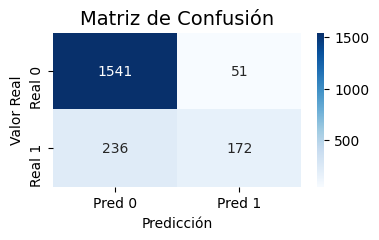

Bosque aleatorio (Sobremuestreo)
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.8440
Precisión: 0.6500
Sensibilidad (Recall): 0.5098
F1-Score: 0.5714
AUC-ROC: 0.8121



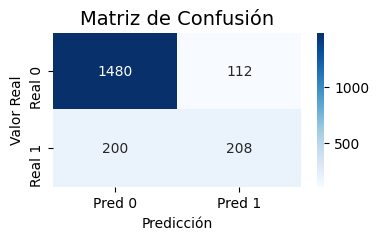

Bosque aleatorio (Submuestreo)
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.6245
Precisión: 0.3353
Sensibilidad (Recall): 0.8554
F1-Score: 0.4817
AUC-ROC: 0.8017



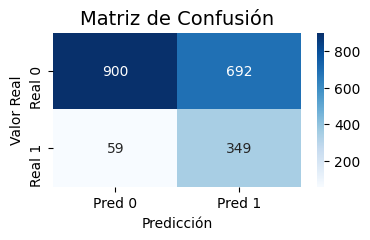

In [14]:
# Crear el modelo de bosque aleatorio
weight_rf = RandomForestClassifier(random_state=r_seed, n_estimators=10, class_weight='balanced')
print("Bosque aleatorio (Peso de clase)")
matrix_weight_rf, accuracy_weight_rf, precision_weight_rf, recall_weight_rf, f1_weight_rf, roc_auc_weight_rf = evaluate_model(weight_rf, 
                                                                                                                            features_train, target_train, 
                                                                                                                            features_valid, target_valid)

# Sobremuestreo
features_upsampled, target_upsampled = upsample(features_train, target_train, 10)

upsampled_rf = RandomForestClassifier(random_state=r_seed, n_estimators=10)
print("Bosque aleatorio (Sobremuestreo)")
matrix_up_rf, accuracy_up_rf, precision_up_rf, recall_up_rf, f1_up_rf, roc_auc_up_rf = evaluate_model(upsampled_rf, 
                                                                                                    features_upsampled, target_upsampled, 
                                                                                                    features_valid, target_valid)

# Submuestreo
features_downsampled, target_downsampled = downsample(features_train, target_train, 0.1)

downsample_fr = RandomForestClassifier(random_state=r_seed, n_estimators=10)
print("Bosque aleatorio (Submuestreo)")
matrix_down_rf, accuracy_down_rf, precision_down_rf, recall_down_rf, f1_down_rf, roc_auc_down_rf = evaluate_model(downsample_fr, 
                                                                                                                features_downsampled, target_downsampled, 
                                                                                                                features_valid, target_valid)

- Sobremuestreo:
    * Logra el mejor F1-Score (0.5714) y AUC-ROC (0.8121) entre las técnicas de balanceo.
    * Mejora el recall sin sacrificar demasiado la precisión.

- Submuestreo:
    * Alto recall (0.8554), pero precisión y exactitud muy bajas.


Mejor modelo después de GridSearch:
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.8535
Precisión: 0.6758
Sensibilidad (Recall): 0.5417
F1-Score: 0.6014
AUC-ROC: 0.8388



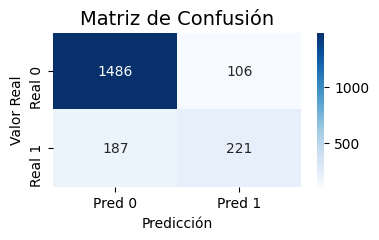

Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [15]:
# Mejor modelo
param_grid_forest = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20], 
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(upsampled_rf, param_grid_forest, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(features_upsampled, target_upsampled,)

best_rf = grid_search.best_estimator_
print("\nMejor modelo después de GridSearch:")
matrix, accuracy, precision, recall, f1, roc_auc = evaluate_model(best_rf, features_upsampled, target_upsampled, features_valid, target_valid)
print("Mejores parámetros:", grid_search.best_params_)

### 💡 Hallazgos:

1. El Bosque Aleatorio base ya era el mejor modelo antes del balanceo, pero su rendimiento en la clase minoritaria (recall) era limitado.
2. El ajuste de clases especialmente sobremuestreo mejora el recall, pero puede perjudicar otras métricas como la precisión y exactitud.
3. El mejor modelo con Bosque Aleatorio con GridSearch logra el mejor equilibrio, optimizando hiperparámetros para mejorar recall y F1-Score sin sacrificar demasiado la exactitud.
4. La Regresión Logística es muy sensible al desequilibrio, y aunque el ajuste de pesos mejora su recall, sigue siendo inferior al Bosque Aleatorio.
5. El submuestreo tiende a empeorar el rendimiento general aunque aumenta recall, mientras que el sobremuestreo es más efectivo en modelos complejos como el Bosque Aleatorio.

## 🧪 Modelo y Prueba Final



Evaluación final en conjunto de prueba:
Métricas de Evaluación
-------------------------------
Exactitud (Accuracy): 0.8515
Precisión: 0.6618
Sensibilidad (Recall): 0.5528
F1-Score: 0.6024
AUC-ROC: 0.8410



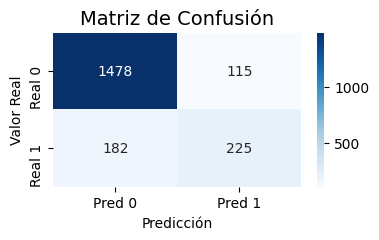


¡El modelo cumple con el requisito mínimo de F1 >= 0.59!


In [16]:
# Evaluación en el conjunto de prueba con el mejor modelo

final_rf = RandomForestClassifier(random_state=r_seed, max_depth=None, min_samples_split=2, n_estimators=100, class_weight='balanced')

print("\nEvaluación final en conjunto de prueba:")
matrix, accuracy, precision, recall, f1, roc_auc = evaluate_model(final_rf, 
                                    features_upsampled, 
                                    target_upsampled, 
                                    features_test, target_test)

# Verificar si cumple con el requisito mínimo
if f1 >= 0.59:
    print("\n¡El modelo cumple con el requisito mínimo de F1 >= 0.59!")
else:
    print("\nEl modelo no alcanza el requisito mínimo de F1 >= 0.59")

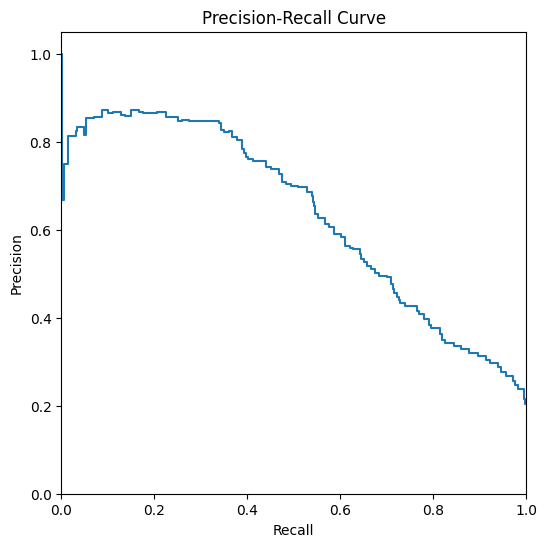

In [17]:
probabilities_valid = best_rf.predict_proba(features_valid)
precision, recall, thresholds = precision_recall_curve(
    target_valid, probabilities_valid[:, 1]
)

plt.figure(figsize=(6, 6))
plt.step(recall, precision, where='post')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve')
plt.show()

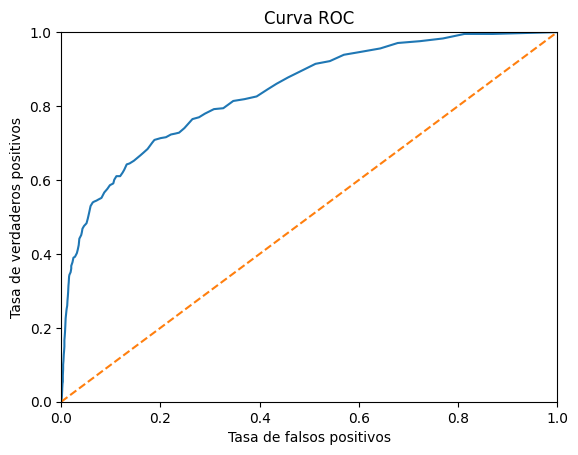

In [18]:
probabilities_valid = best_rf.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.show()

### 📜 Conclución:
* Usar el Bosque Aleatorio optimizado con GridSearch como modelo final, ya que ofrece el mejor equilibrio entre detección de la clase minoritaria y rendimiento general.
* Si se prioriza capturar más casos positivos a costa de más falsos positivos, se podría usar el modelo con sobremuestreo.